In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
sns.set()

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
data = pd.read_csv("/content/drive/MyDrive/Statistics/campaigns.csv")
data.head(10)

,OutletID,MarketSize,AgeofOutlets,Campaigns,Week,SalesInThousands
0,1,Medium,4,3,1,33.73
1,1,Medium,4,3,2,35.67
2,1,Medium,4,3,3,29.03
3,1,Medium,4,3,4,39.25
4,2,Medium,5,2,1,27.81
5,2,Medium,5,2,2,34.67
6,2,Medium,5,2,3,27.98
7,2,Medium,5,2,4,27.72
8,3,Medium,12,1,1,44.54
9,3,Medium,12,1,2,37.94


In [5]:
print("Data specification")
print(f"Rows: {data.shape[0]}")
print(f"Columns: {data.shape[1]}")
print(f"Features: {data.columns.to_list()}")
print(f"Missing values: {data.isnull().values.sum()}")
print("------------------------------------------")
print("------------------------------------------")
print(f"unique values:\n{data.nunique()}")


Data specification
Rows: 548
Columns: 6
Features: ['OutletID', 'MarketSize', 'AgeofOutlets', 'Campaigns', 'Week', 'SalesInThousands']
Missing values: 0
------------------------------------------
------------------------------------------
unique values:
OutletID            137
MarketSize            3
AgeofOutlets         25
Campaigns             3
Week                  4
SalesInThousands    517
dtype: int64


In [6]:
data.describe()

,OutletID,AgeofOutlets,Campaigns,Week,SalesInThousands
count,548.000000,548.000000,548.000000,548.000000,548.000000
mean,479.656934,8.503650,2.029197,2.500000,53.466204
std,287.973679,6.638345,0.810729,1.119055,16.755216
min,1.000000,1.000000,1.000000,1.000000,17.340000
25%,216.000000,4.000000,1.000000,1.750000,42.545000
50%,504.000000,7.000000,2.000000,2.500000,50.200000
75%,708.000000,12.000000,3.000000,3.250000,60.477500
max,920.000000,28.000000,3.000000,4.000000,99.650000


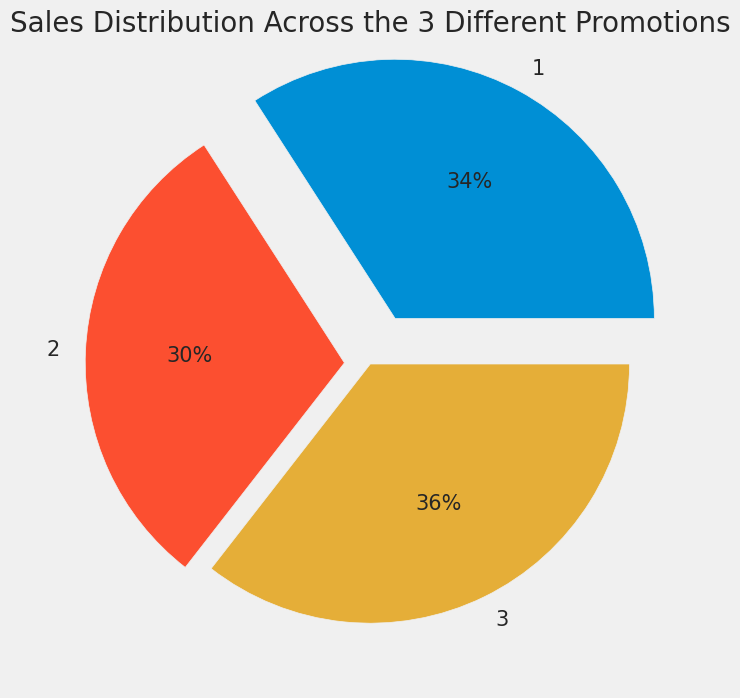

In [7]:
plt.style.use("fivethirtyeight")
ax = data.groupby("Campaigns").sum()["SalesInThousands"].plot.pie(figsize = (8,8),
                                                                  autopct = '%1.0f%%',
                                                                  explode = (0.2, 0.1, 0),
                                                                  textprops = {'fontsize' : 15})
ax.set_ylabel("")
ax.set_title('Sales Distribution Across the 3 Different Promotions', fontsize = 20)

plt.show()

In [8]:
data2 = data.groupby(["Campaigns", "MarketSize"]).count()["OutletID"].unstack("MarketSize")
data2

MarketSize,Large,Medium,Small
Campaigns,,,
1,56,96,20
2,64,108,16
3,48,116,24


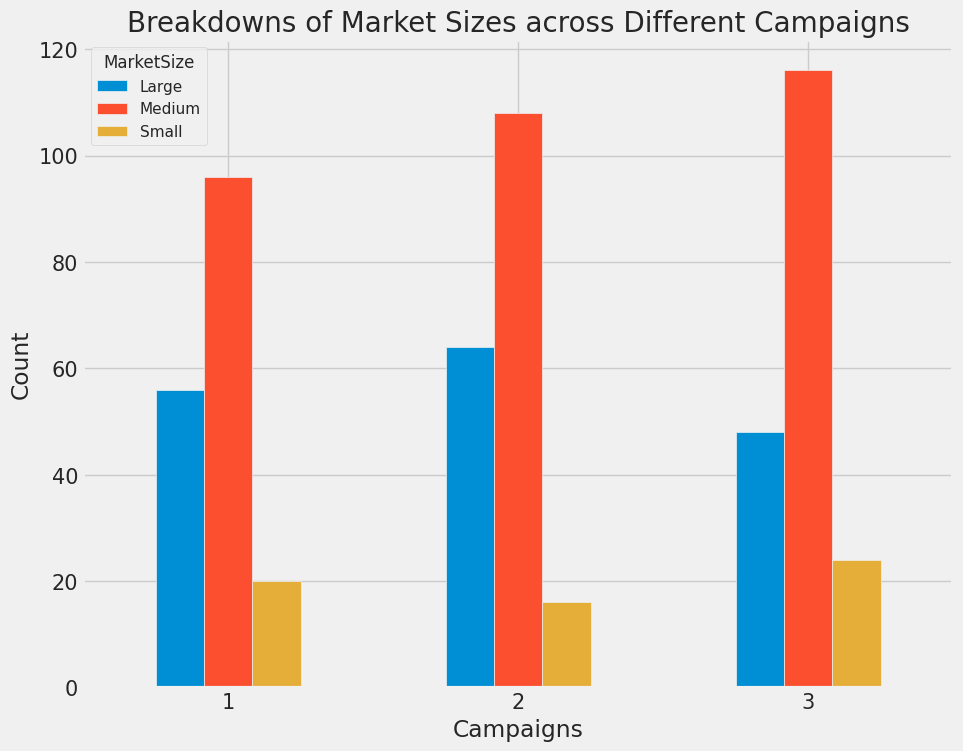

In [9]:
ax = data2.plot(kind= 'bar', figsize = (10,8), grid=True)

ax.tick_params(axis = 'x', labelsize= 15)
plt.xticks(rotation = 'horizontal')
ax.tick_params(axis = 'y', labelsize = 15)
ax.set_ylabel('Count')
ax.set_title('Breakdowns of Market Sizes across Different Campaigns', fontsize = 20)


plt.show()

In [10]:
data3 = data.groupby("AgeofOutlets").count()["OutletID"]
data3

,OutletID
AgeofOutlets,
1,80
2,20
3,32
4,44
5,44
6,36
7,40
8,40
9,28


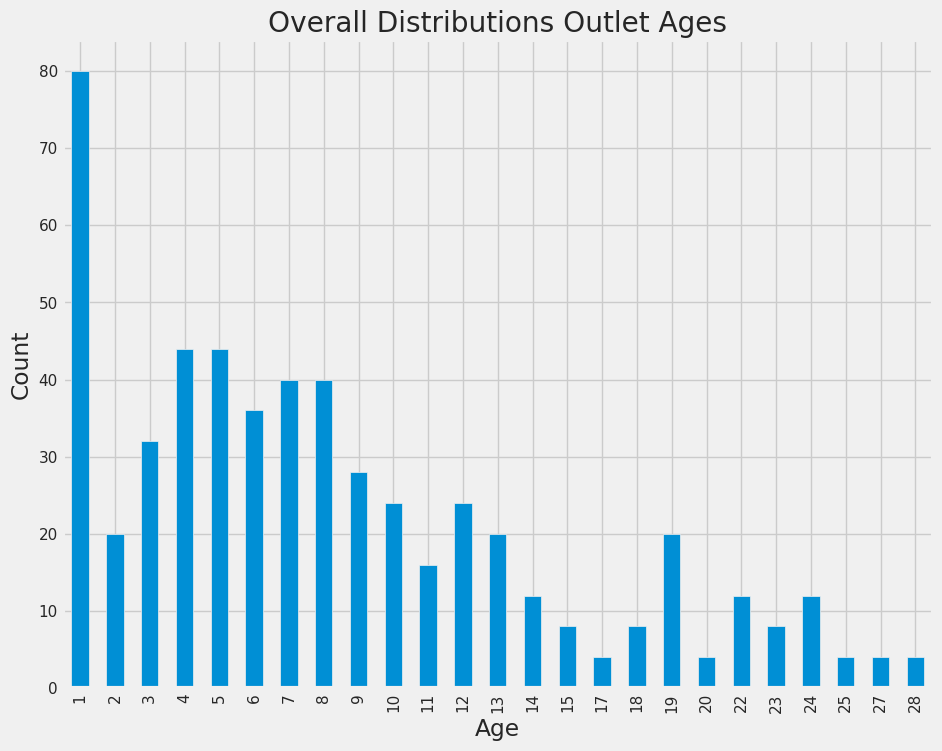

In [11]:
ax = data3.plot(kind= 'bar', figsize = (10,8), grid=True)

ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.set_title('Overall Distributions Outlet Ages')

plt.show()


In [12]:
data4 = data.groupby(['AgeofOutlets', 'Campaigns']).count()['OutletID'].unstack('Campaigns').iloc[::-1]
data4

Campaigns,1,2,3
AgeofOutlets,,,
28,NaN,4.0,NaN
27,4.0,NaN,NaN
25,NaN,4.0,NaN
24,4.0,NaN,8.0
23,NaN,4.0,4.0
22,4.0,NaN,8.0
20,NaN,NaN,4.0
19,4.0,8.0,8.0
18,8.0,NaN,NaN


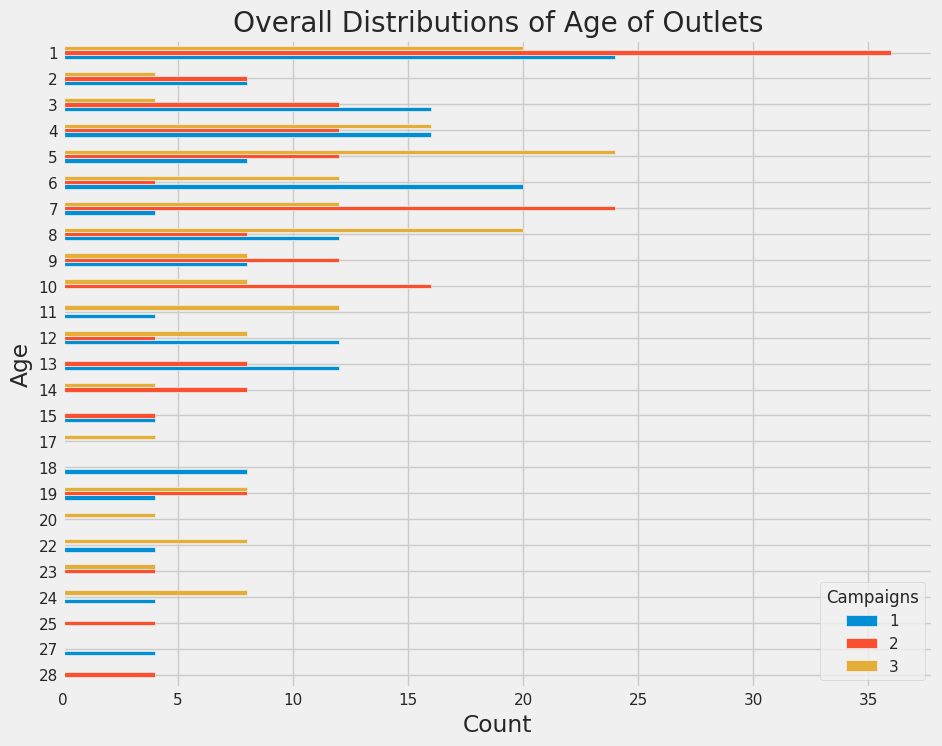

In [13]:
ax = data4.plot(kind= 'barh', figsize = (10,8), grid=True)
ax.set_ylabel('Age')
ax.set_xlabel('Count')
ax.set_title('Overall Distributions of Age of Outlets')

plt.show()

In [14]:
data.groupby('Campaigns').describe()['AgeofOutlets']

,count,mean,std,min,25%,50%,75%,max
Campaigns,,,,,,,,
1,172.0,8.279070,6.636160,1.0,3.0,6.0,12.0,27.0
2,188.0,7.978723,6.597648,1.0,3.0,7.0,10.0,28.0
3,188.0,9.234043,6.651646,1.0,5.0,8.0,12.0,24.0


# Performing A/B Testing on Three Marketing Campaigns

In [15]:
data

,OutletID,MarketSize,AgeofOutlets,Campaigns,Week,SalesInThousands
0,1,Medium,4,3,1,33.73
1,1,Medium,4,3,2,35.67
2,1,Medium,4,3,3,29.03
3,1,Medium,4,3,4,39.25
4,2,Medium,5,2,1,27.81
...,...,...,...,...,...,...
543,919,Large,2,1,4,64.34
544,920,Large,14,2,1,50.20
545,920,Large,14,2,2,45.75
546,920,Large,14,2,3,44.29


In [16]:
Means = data.groupby('Campaigns')["SalesInThousands"].mean()
Stds = data.groupby('Campaigns')["SalesInThousands"].std()
Obsv = data.groupby('Campaigns')["SalesInThousands"].count()

print(f'===== MEAN ====== \n{Means}\n')
print(f'===== STANDARD DEVIATION ====== \n{Stds}\n')
print(f'===== OBSERVATIONS ====== \n{Obsv}\n')

===== MEAN ====== 
Campaigns
1    58.099012
2    47.329415
3    55.364468
Name: SalesInThousands, dtype: float64

===== STANDARD DEVIATION ====== 
Campaigns
1    16.553782
2    15.108955
3    16.766231
Name: SalesInThousands, dtype: float64

===== OBSERVATIONS ====== 
Campaigns
1    172
2    188
3    188
Name: SalesInThousands, dtype: int64



In [17]:
data

,OutletID,MarketSize,AgeofOutlets,Campaigns,Week,SalesInThousands
0,1,Medium,4,3,1,33.73
1,1,Medium,4,3,2,35.67
2,1,Medium,4,3,3,29.03
3,1,Medium,4,3,4,39.25
4,2,Medium,5,2,1,27.81
...,...,...,...,...,...,...
543,919,Large,2,1,4,64.34
544,920,Large,14,2,1,50.20
545,920,Large,14,2,2,45.75
546,920,Large,14,2,3,44.29


# A/B Testing: 1st Campaigns vs 2nd Campaigns

In [20]:
t, p = stats.ttest_ind(data.loc[data['Campaigns'] == 1, 'SalesInThousands'].values,
                       data.loc[data['Campaigns'] == 2, 'SalesInThousands'].values,
                       equal_var= False)

In [21]:
print(f"t_value: {t}")
print(f"p_value: {p}")

t_value: 6.42752867090748
p_value: 4.2903687179871785e-10


### Analysis of P and t-values (1 vs 2)

Our p-Value is close to 0 which means that there is good evidence to **reject the null hypothesis**. Meaning the there is a statistical difference between the two groups. Our threshold rejectings the Null is usually less than 0.05.

Furthermore, the t-test shows that the marketing performances for these two groups are significantly different and that first marketing campaigns outperforms second marketing campaigns.

# A/B Testing: 1st Campaigns vs 3rd Campaigns

In [22]:
t, p = stats.ttest_ind(data.loc[data['Campaigns'] == 1, 'SalesInThousands'].values,
                       data.loc[data['Campaigns'] == 3, 'SalesInThousands'].values,
                       equal_var= False)

In [25]:
print(data.loc[data['Campaigns'] == 1, 'SalesInThousands'].mean())
print(data.loc[data['Campaigns'] == 3, 'SalesInThousands'].mean())

58.09901162790698
55.36446808510639


In [23]:
print(f"t_value: {t}")
print(f"p_value: {p}")

t_value: 1.5560224307758634
p_value: 0.12059147742229478


### Analysis of P and t-values (1 vs 3)

We note that the average sales from first marketing campaigns (58.1) is higher than those from third marketing campaigns (55.36).
But, running a t-test between these two groups, gives us a t-value of 1.556 and a p-value of 0.121.
The computed **p-value is a lot higher than 0.05**, past the threshold for statistical significance.

# A/B Testing: 2nd Campaigns vs 3rd Campaigns

In [26]:
t, p = stats.ttest_ind(data.loc[data['Campaigns'] == 2, 'SalesInThousands'].values,
                       data.loc[data['Campaigns'] == 3, 'SalesInThousands'].values,
                       equal_var= False)

In [28]:
print(data.loc[data['Campaigns'] == 2, 'SalesInThousands'].mean())
print(data.loc[data['Campaigns'] == 3, 'SalesInThousands'].mean())

47.32941489361701
55.36446808510639


In [27]:
print(f"t_value: {t}")
print(f"p_value: {p}")

t_value: -4.88139271089348
p_value: 1.5692733176039892e-06


# Analysis of P and t-values (2 vs 3)

Based on the average sales, second marketing campaigns (47.33) is higher than those from third marketing campaigns (55.36).
If we run the t-test and between these two campaigns, results shows that the p-value (0.000001569) is lower than 0.05 threshold, which concludes that it **rejects null hypotheses**. In other words, there's statistical difference between second marketing campaigns and third marketing campaigns.